# Applying demand tariffs to a btm site
This example shows how to build demand tariffs out of a combination of demand charges. It also shows the two ways of defining time periods over which the tariff applies.

## Build the model (see btm_battery_example for more details on this process)

In [1]:
import numpy as np
from echo.echo_models import *
from echo.echo_optimiser import *
from echo.objectives import *

In [2]:
time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1  # Number of planning intervals - in echo V1, set to 1 always

In [3]:
load_array = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 15, 15, 15, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 12, 12])

pv_array = 2 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

pv_array *= -1  # use positive load convention, so solar gen is negative

In [4]:
system = OptimisationGraph()

In [5]:
grid = Node() # create node representing upstream grid
grid.add_electrical_ports_from_list(['grid'])

In [6]:
connection_point = TellegenNode()     # create the connection point node
connection_point.add_electrical_ports_from_list(['load', 'inv', 'grid'])  # add ports with easily referenced names

In [7]:
load = Node()                       # create a node to represent the load
load_port = ElectricalDemand()             # create an electrical demand port to attach to this node
load_port.add_demand_profile_from_array(load_array, expansion_periods)
load.ports['load'] = load_port # explicitly add the load_port to the dictionary of node ports

In [8]:
inverter = Inverter(max_import=None,
                    max_export=None,
                    dc_ac_efficiency=1,
                    ac_dc_efficiency=1)

inverter.add_ac_port('inv')     # add a port with name 'inv' that is used to connect upstream/ac side
inverter.add_dc_port('battery')    # add a port with name 'battery' to connect to the battery
inverter.add_dc_port('pv')      # add a port with name 'pv' for us to connect the pv node into

In [9]:
# create a node for the battery
battery = Node()
# create an electrical storage object
battery_port = ElectricalStorage(max_capacity=15.0,                # max capacity of battery in kwh
                       depth_of_discharge_limit=0,      # allowable depth of discharge in range [0,100] (i.e. percent)
                       charging_power_limit=1.25,       # max charging rate in kW
                       discharging_power_limit=-1.25,   # max discharging rate in kW
                       charging_efficiency=1,           # charging efficiency in range [0,1]
                       discharging_efficiency=1,        # discharging efficiency in range [0,1]
                       initial_state_of_charge=0.0)     # initial state of charge in kWh

battery.ports['battery'] = battery_port

In [10]:
# create a node for the solar
solar = Node()
solar_port = ElectricalGeneration()     # create an electrical generation object
solar_port.curtailable = False          # set whether this can be curtailed or not
solar_port.add_generation_profile_from_array(pv_array, expansion_periods)
solar.ports['pv'] = solar_port        # add the solar port to the dictionary of node ports

In [11]:
system.add_node_obj([grid, connection_point, load, inverter, solar, battery])  # nodes can be added one by one or as a list

In [12]:
# Add edges to graph
system.connect_ports_and_create_edge(grid.ports['grid'], connection_point.ports['grid'])
system.connect_ports_and_create_edge(connection_point.ports['load'], load.ports['load'])
system.connect_ports_and_create_edge(connection_point.ports['inv'], inverter.ports['inv'])
system.connect_ports_and_create_edge(inverter.ports['battery'], battery.ports['battery'])
system.connect_ports_and_create_edge(inverter.ports['pv'], solar.ports['pv'])

## Create objectives
Here we will create an import demand tariff, which consists of two demand charges - a shoulder charge, and a peak period charge.

## Define peak period demand charge
A demand charge has three components:
- a rate (in $/kW or equivalent $/unit flow)
- a window, which indicates the window over which the max demand is calculated. If the charge applies over multiple windows the maximum over those multiple windows is calculated.
- a reset period, which indicates how often the calculation resets. This should be defined as a list of time intervals per reset period. If the charge never resets, set reset_period=[number of time intervals]


In [15]:
# create an import demand tariff
# peak usage
peak_rate = 2.0  # the rate is applied per kW
peak_window = [0]*28 + [1]*8 + [0]*36 + [1]*12 + [0]*12  # binary array where 1 indicates when the charge applies

peak_charge = ImportDemandCharge(rate=peak_rate,
                           window_array=peak_window,
                           min_demand=0.0,  # min demand can be used to move the 'floor' on the demand calculation. Default is 0.0
                           reset_periods=[96])

## Define an off peak demand charge
Same process as above

In [17]:
shoulder_rate = 1.0
shoulder_window = [0]*36 + [1]*36 + [0]*12 + [1]*8 + [0]*4

shoulder_charge = ImportDemandCharge(rate=shoulder_rate,
                               window_array=shoulder_window,
                               min_demand=0.0,
                               reset_periods=[96])

### Create a demand tariff echo objective by combining these demand charges

In [18]:
demand_tariff = DemandTariffObjective(component=connection_point.ports['grid'],
                                      demand_charges=[peak_charge, shoulder_charge])

# Create echo objective set which is a list of objectives
objective_set = ObjectiveSet(objective_list=[demand_tariff])


## Run the optimiser

In [19]:
# Invoke the optimiser
optimiser = EchoOptimiser(interval_duration=interval_duration,
                          number_of_intervals=time_periods,
                          number_of_expansion_intervals=expansion_periods,
                          discount_rate=0,
                          ES=system,
                          objective_set=objective_set,
                          optimiser_engine='cplex')

# Optimise
optimiser.optimise()

## Print some results
we can look at the cost per demand charge within the demand objective, or the cost of the demand objective as a whole.
We simply use the optimiser.values() function on the max_demand_val variable, which is stored on each demand charge object.


In [20]:
print(optimiser.values(peak_charge.max_demand_val))
print(optimiser.values(shoulder_charge.max_demand_val))

[1.88]
[1.61]


we can also look at the objective value for the overall demand tariff and compare it to the total to check that it adds up correctly.

In [21]:
print(optimiser.get_single_objective_total_value(demand_tariff))
print(optimiser.get_total_objective_value())

5.3699999999999966
5.3699999999999966


## Print some results
we can look at the cost per demand charge within the demand objective, or the cost of the demand objective as a whole.
We simply use the optimiser.values() function on the max_demand_val variable, which is stored on each demand charge object.


In [25]:
print('Peak charge maximum demand: ', optimiser.values(peak_charge.max_demand_val))
print('Shoulder charge maximum demand: ', optimiser.values(shoulder_charge.max_demand_val))

Peak charge cost:  [1.88]
Shoulder charge cost:  [1.61]


we can also look at the objective value for the overall demand tariff and compare it to the total to check that it adds up correctly.

In [27]:
peak_cost = optimiser.values(peak_charge.max_demand_val)*peak_rate
shoulder_cost = optimiser.values(shoulder_charge.max_demand_val)*shoulder_rate
print('Peak charge cost: ', peak_cost)
print('Shoulder charge cost: ', shoulder_cost)
print('Sum of costs: ', sum([i + j for i in peak_cost for j in shoulder_cost]))

print('Total demand charge cost: ',optimiser.get_single_objective_total_value(demand_tariff))


Peak charge cost:  [3.76]
Shoulder charge cost:  [1.61]
Sum of costs:  5.3699999999999966
Total demand charge cost:  5.3699999999999966


## Plot some results

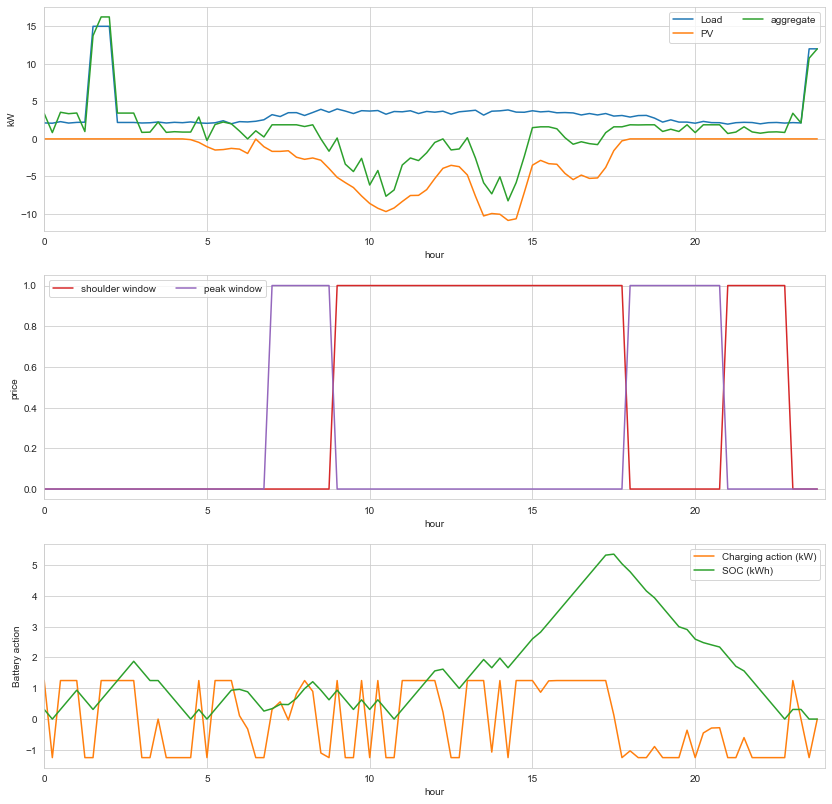

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get optimised results
# These are retrieved by calling the optimiser .values() method, and providing the variable name we want.
# In this case, the storage port has two variables of interest - port_name, which is the battery power, and soc_value

storage_energy_delta = optimiser.values(battery_port.port_name, 0)
storage_energy_soc = optimiser.values(battery_port.soc_value, 0)
optimised_connection_point_load = optimiser.values(connection_point.ports['grid'].port_name, 0)


# Do plotting
colors = sns.color_palette()
hrs = np.arange(0, len(load_array)) / 4
fig = plt.figure(figsize=(14, 14))
ax1 = fig.add_subplot(3, 1, 1)
line1, = ax1.plot(hrs, load_array, color=colors[0])
line2, = ax1.plot(hrs, pv_array, color=colors[1])
line3, = ax1.plot(hrs, optimised_connection_point_load, color=colors[2])
ax1.set_xlabel('hour'), ax1.set_ylabel('kW')
ax1.legend([line1, line2, line3], ['Load', 'PV', 'aggregate'], ncol=2)
ax1.set_xlim([0, len(load_array) / 4])

ax2 = fig.add_subplot(3, 1, 2)
line1, = ax2.plot(hrs, shoulder_window, color=colors[3])
line2, = ax2.plot(hrs, peak_window, color=colors[4])
ax2.set_xlabel('hour'), ax2.set_ylabel('price')
ax2.legend([line1, line2], ['shoulder window', 'peak window'], ncol=2)
ax2.set_xlim([0, len(load_array) / 4])

ax3 = fig.add_subplot(3, 1, 3)
line1, = ax3.plot(hrs, storage_energy_delta, color=colors[1])
line2, = ax3.plot(hrs, storage_energy_soc, color=colors[2])
ax3.set_xlim([0, len(load_array) / 4])
ax3.set_xlabel('hour'), ax3.set_ylabel('Battery action')
ax3.legend([line1, line2], ['Charging action (kW)', 'SOC (kWh)'])
plt.show()
